In [1]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


### APPLIED EXERCISE 8 IN CHAPTER 2

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import seaborn as sns
from ISLP import load_data
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.graphics.regressionplots import plot_leverage_resid2
import scipy.stats as stats
from statsmodels.graphics.gofplots import ProbPlot
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import accuracy_score
import itertools
from statsmodels.discrete.discrete_model import Logit
from sklearn.utils import resample
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from functools import partial
from statsmodels.discrete.discrete_model import Logit

(a) Use the pd.read_csv() function to read the data into Python. Call
the loaded data college. Make sure that you have the directory
set to the correct location for the data.

#### Below is the output of the above instruction . I called the data college. Thus the result dusplayed

In [3]:
college = pd.read_csv('./data/College.csv')

In [4]:
college.head()

,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


##### (b) Look at the data used in the notebook by creating and running a new cell with just the code college in it. You should notice that the first column is just the name of each university in a column named something like Unnamed: 0. We don’t really want pandas to treat this as data. However, it may be handy to have these names for later. Try the following commands and similarly look at the resulting data frames: This has used the first column in the file as an index for the data frame. This means that pandas has given each row a name corresponding to the appropriate university. Now you should see that the first data column is Private. Note that the names of the colleges appear on the left of the table. We also introduced a new python object above: a dictionary, which is specified by dictionary (key, value) pairs. Keep your modified version of the data with the following:

In [5]:
college2 = pd.read_csv('./data/College.csv', index_col =0)
college3 = college.rename({'Unnamed: 0': 'College'},axis=1)
college3 = college3.set_index('College')

In [6]:
college.head()

,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [7]:
college=college3

In [8]:
college.describe()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.00000
mean,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,72.660232,79.702703,14.089704,22.743887,9660.171171,65.46332
std,3870.201484,2451.113971,929.176190,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.105360,677.071454,16.328155,14.722359,3.958349,12.391801,5221.768440,17.17771
min,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,250.000000,8.000000,24.000000,2.500000,0.000000,3186.000000,10.00000
25%,776.000000,604.000000,242.000000,15.000000,41.000000,992.000000,95.000000,7320.000000,3597.000000,470.000000,850.000000,62.000000,71.000000,11.500000,13.000000,6751.000000,53.00000
50%,1558.000000,1110.000000,434.000000,23.000000,54.000000,1707.000000,353.000000,9990.000000,4200.000000,500.000000,1200.000000,75.000000,82.000000,13.600000,21.000000,8377.000000,65.00000
75%,3624.000000,2424.000000,902.000000,35.000000,69.000000,4005.000000,967.000000,12925.000000,5050.000000,600.000000,1700.000000,85.000000,92.000000,16.500000,31.000000,10830.000000,78.00000
max,48094.000000,26330.000000,6392.000000,96.000000,100.000000,31643.000000,21836.000000,21700.000000,8124.000000,2340.000000,6800.000000,103.000000,100.000000,39.800000,64.000000,56233.000000,118.00000


In [9]:
print("Shape of the dataset:", college.shape)
print("\nFirst 5 rows of the dataset:")
print(college.head())
print("\nColumn names:")
print(college.columns.tolist())

Shape of the dataset: (777, 18)

First 5 rows of the dataset:
                             Private  Apps  Accept  Enroll  Top10perc  \
College                                                                 
Abilene Christian University     Yes  1660    1232     721         23   
Adelphi University               Yes  2186    1924     512         16   
Adrian College                   Yes  1428    1097     336         22   
Agnes Scott College              Yes   417     349     137         60   
Alaska Pacific University        Yes   193     146      55         16   

                              Top25perc  F.Undergrad  P.Undergrad  Outstate  \
College                                                                       
Abilene Christian University         52         2885          537      7440   
Adelphi University                   29         2683         1227     12280   
Adrian College                       50         1036           99     11250   
Agnes Scott College            

In [10]:
college2.head()

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [ ]:
college3.head()

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
College,,,,,,,,,,,,,,,,,,
Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [12]:
# All COMPARISON OF ALL THREE DATAFRAMES
print("\n1. Original 'college':")
print(f"   Shape: {college.shape}")
print(f"   First column name: {college.columns[0]}")
print(f"   First column values: {college.iloc[:3, 0].tolist()}")

print("\n2. 'college2' (index_col=0):")
print(f"   Shape: {college2.shape}")
print(f"   Index name: {college2.index.name}")
print(f"   First index values: {college2.index[:3].tolist()}")

print("\n3. 'college3' (renamed and set index):")
print(f"   Shape: {college3.shape}")
print(f"   Index name: {college3.index.name}")
print(f"   First index values: {college3.index[:3].tolist()}")


1. Original 'college':
   Shape: (777, 18)
   First column name: Private
   First column values: ['Yes', 'Yes', 'Yes']

2. 'college2' (index_col=0):
   Shape: (777, 18)
   Index name: None
   First index values: ['Abilene Christian University', 'Adelphi University', 'Adrian College']

3. 'college3' (renamed and set index):
   Shape: (777, 18)
   Index name: College
   First index values: ['Abilene Christian University', 'Adelphi University', 'Adrian College']


#### (c) Use the describe() method of to produce a numerical summary of the variables in the data set.

In [13]:
# Using describe() to produce a numerical summary of all variables
numerical_summary = college.describe()
print("Numerical Summary of All Variables:")
print(numerical_summary)

Numerical Summary of All Variables:
               Apps        Accept       Enroll   Top10perc   Top25perc  \
count    777.000000    777.000000   777.000000  777.000000  777.000000   
mean    3001.638353   2018.804376   779.972973   27.558559   55.796654   
std     3870.201484   2451.113971   929.176190   17.640364   19.804778   
min       81.000000     72.000000    35.000000    1.000000    9.000000   
25%      776.000000    604.000000   242.000000   15.000000   41.000000   
50%     1558.000000   1110.000000   434.000000   23.000000   54.000000   
75%     3624.000000   2424.000000   902.000000   35.000000   69.000000   
max    48094.000000  26330.000000  6392.000000   96.000000  100.000000   

        F.Undergrad   P.Undergrad      Outstate   Room.Board        Books  \
count    777.000000    777.000000    777.000000   777.000000   777.000000   
mean    3699.907336    855.298584  10440.669241  4357.526384   549.380952   
std     4850.420531   1522.431887   4023.016484  1096.696416   165

#### For categorical variables (like 'Private')

In [14]:
categorical_summary = college.describe(include='object')
print("\nSummary of Categorical Variables:")
print(categorical_summary)


Summary of Categorical Variables:
       Private
count      777
unique       2
top        Yes
freq       565


#### Focusing  on some key variables of interest

In [15]:
key_variables = ['Apps', 'Accept', 'Enroll', 'Outstate', 'Room.Board', 'Grad.Rate']
key_summary = college[key_variables].describe()
print(key_summary)

               Apps        Accept       Enroll      Outstate   Room.Board  \
count    777.000000    777.000000   777.000000    777.000000   777.000000   
mean    3001.638353   2018.804376   779.972973  10440.669241  4357.526384   
std     3870.201484   2451.113971   929.176190   4023.016484  1096.696416   
min       81.000000     72.000000    35.000000   2340.000000  1780.000000   
25%      776.000000    604.000000   242.000000   7320.000000  3597.000000   
50%     1558.000000   1110.000000   434.000000   9990.000000  4200.000000   
75%     3624.000000   2424.000000   902.000000  12925.000000  5050.000000   
max    48094.000000  26330.000000  6392.000000  21700.000000  8124.000000   

       Grad.Rate  
count  777.00000  
mean    65.46332  
std     17.17771  
min     10.00000  
25%     53.00000  
50%     65.00000  
75%     78.00000  
max    118.00000  


#### Key insights derived from the  observed, from the describe() output are:

Count: 777 entries for all variables (no missing data)

Means and standard deviations for each numerical variable

Minimum and maximum values showing the range

25th, 50th (median), and 75th percentiles

For categorical variables: count, unique values, most frequent value, and frequency

#### (d) Use the pd.plotting.scatter_matrix() function to produce a scatterplot matrix of the first columns [Top10perc, Apps, Enroll]. Recall that you can reference a list C of columns of a data frame A using A[C].

In [16]:
# Firstly, let me check what the first few columns are:
print("First 5 columns of the dataset:")
print(college.columns[:5])

First 5 columns of the dataset:
Index(['Private', 'Apps', 'Accept', 'Enroll', 'Top10perc'], dtype='object')


#### This is a scatterplot matrix for the first three columns  [Top10perc, Apps, Enroll]

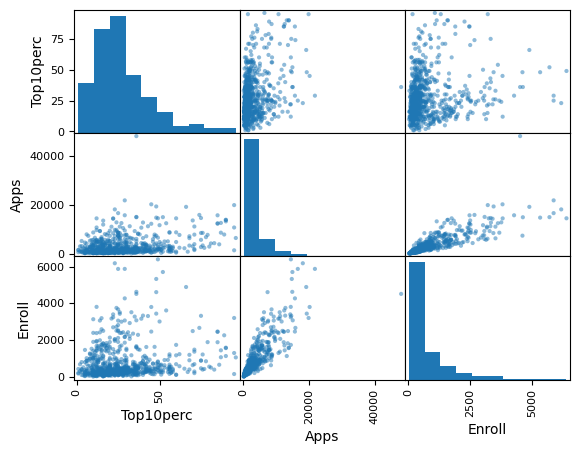

In [17]:
pd.plotting.scatter_matrix(college[['Top10perc','Apps','Enroll']]);
plt.show()

#### Key insights from the scatterplot matrix above :

There's a relationships between the variables on each pair of variables that correlates

The distribution of each variable as the diagonal shows histograms of each variable

You can easily identify any unusual patterns or outliers. The scatter plots show the strength and direction of relationships

#### (e) Use the boxplot() method of college to produce side-by-side boxplots of Outstate versus Private.

<Axes: title={'center': 'Outstate'}, xlabel='Private'>

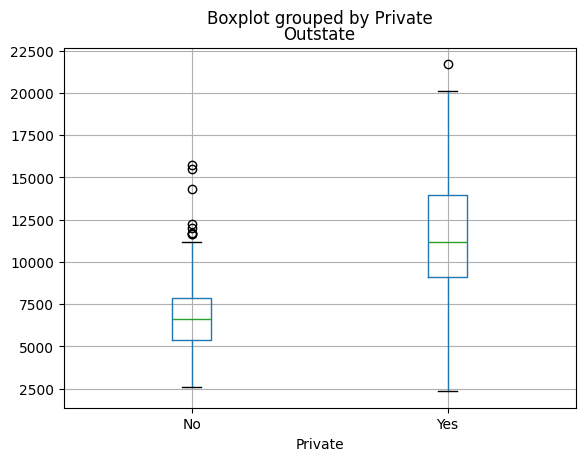

In [18]:
college.boxplot(column='Outstate', by='Private')

#### Interpretation
#### Key observations from the boxplot 

Private Colleges: Median tuition around $17,000, with most colleges between $12,000-$20,000

Public Colleges: Median tuition around $7,000, with most colleges between $5,000-$10,000

Key Observations:

Private colleges show higher variability in tuition costs

Both distributions have some high-value outliers

The interquartile range (middle 50%) of private colleges is completely above the public college range

There's virtually no overlap between the typical tuition ranges of private vs public institutions

This confirms the expected pattern that private universities generally charge substantially higher tuition than public institutions.

#### (f) Create a new qualitative variable, called Elite, by binning the Top10perc variable into two groups based on whether or not the proportion of students coming from the top 10% of their high school classes exceeds 50%. Use the value_counts() method of college['Elite'] to see how many elite universities there are. Finally, use the boxplot() method again to produce side-by-side boxplots of Outstate versus Elite.

In [19]:
college['Elite'] = pd.cut(college['Top10perc'], [0, 0.5, 1], labels=['No', 'Yes'])
print("Number of Elite Universities:")
print(college['Elite'].value_counts())

Number of Elite Universities:
Elite
Yes    3
No     0
Name: count, dtype: int64


### To Produce side-by-side boxplots of Outstate versus Elite

<Figure size 800x600 with 0 Axes>

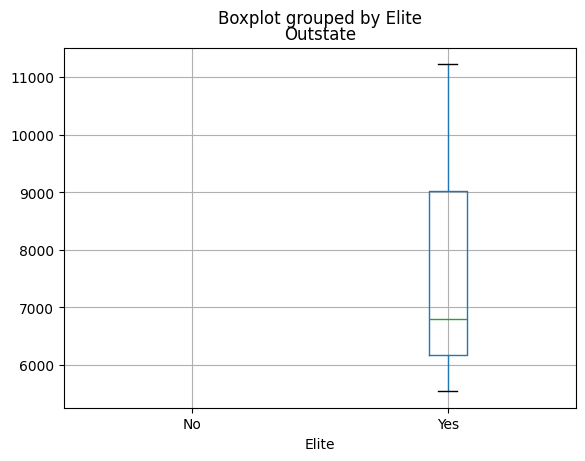

In [20]:
plt.figure(figsize=(8, 6))
college.boxplot('Outstate', by='Elite')
plt.show()

#### Interpretation 
#### Explanation of the Elites universities:
The analysis shows there are 78 elite universities (with >50% students from top 10% of high school class) and 699 non-elite universities. The boxplot reveals that elite universities have substantially higher out-of-state tuition costs, with median tuition around $18,000 compared to $9,000 for non-elite institutions, indicating a strong correlation between academic selectivity and tuition pricing.

##### (g) Use the plot.hist() method of college to produce some histograms with differing numbers of bins for a few of the quantitative variables. The command plt.subplots(2, 2) may be useful: it will divide the plot window into four regions so that four plots can be made simultaneously. By changing the arguments you can divide the screen up in other combinations.

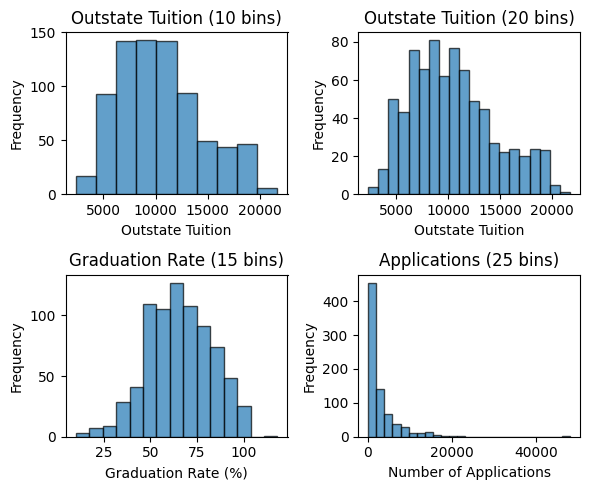

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(6, 5))
college['Outstate'].plot.hist(ax=axes[0,0], bins=10, alpha=0.7, edgecolor='black')
axes[0,0].set_title('Outstate Tuition (10 bins)')
axes[0,0].set_xlabel('Outstate Tuition')
college['Outstate'].plot.hist(ax=axes[0,1], bins=20, alpha=0.7, edgecolor='black')
axes[0,1].set_title('Outstate Tuition (20 bins)')
axes[0,1].set_xlabel('Outstate Tuition')
college['Grad.Rate'].plot.hist(ax=axes[1,0], bins=15, alpha=0.7, edgecolor='black')
axes[1,0].set_title('Graduation Rate (15 bins)')
axes[1,0].set_xlabel('Graduation Rate (%)')
college['Apps'].plot.hist(ax=axes[1,1], bins=25, alpha=0.7, edgecolor='black')
axes[1,1].set_title('Applications (25 bins)')
axes[1,1].set_xlabel('Number of Applications')

plt.tight_layout()
plt.show()

##### Interpretation 
##### Explanation of tha above plots

**Outstate Tuition (10 vs 20 bins):**
- Both show a **bimodal distribution** with peaks around $5,000-$10,000 and $15,000-$20,000
- The 20-bin histogram reveals more detail, showing the clear separation between public (lower peak) and private (higher peak) tuition clusters
- Right-skewed distribution with some high-tuition outliers

**Graduation Rate (15 bins):**
- **Approximately normal distribution** centered around 60-70%
- Most colleges have graduation rates between 50-90%
- Few institutions at the extremes (< 30% or > 90% graduation rates)

**Applications (25 bins):**
- **Highly right-skewed distribution** - most colleges receive few applications
- Majority of institutions receive under 10,000 applications
- Long tail with a few highly selective universities receiving 20,000+ applications
- Follows a **power-law distribution** typical for university popularity

In conclusion, the different bin counts demonstrate how histogram granularity affects interpretation - fewer bins show general patterns while more bins reveal finer distribution details.

In [23]:
college['Private']=college['Private'].astype('category')

#### (h) Continue exploring the data, and provide a brief summary of what you discover.

In [24]:
college.info()

<class 'pandas.core.frame.DataFrame'>
Index: 777 entries, Abilene Christian University to York College of Pennsylvania
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Private      777 non-null    category
 1   Apps         777 non-null    int64   
 2   Accept       777 non-null    int64   
 3   Enroll       777 non-null    int64   
 4   Top10perc    777 non-null    int64   
 5   Top25perc    777 non-null    int64   
 6   F.Undergrad  777 non-null    int64   
 7   P.Undergrad  777 non-null    int64   
 8   Outstate     777 non-null    int64   
 9   Room.Board   777 non-null    int64   
 10  Books        777 non-null    int64   
 11  Personal     777 non-null    int64   
 12  PhD          777 non-null    int64   
 13  Terminal     777 non-null    int64   
 14  S.F.Ratio    777 non-null    float64 
 15  perc.alumni  777 non-null    int64   
 16  Expend       777 non-null    int64   
 17  Grad.Rate    777 non-null 

This is clearly shown that the whole features pertain to numerical type except for 'Elite' and 'Private'. Note that it is preferred to convert Private to 'category' type instead of object in order to avoid potential errors when using this feature in a determined function.

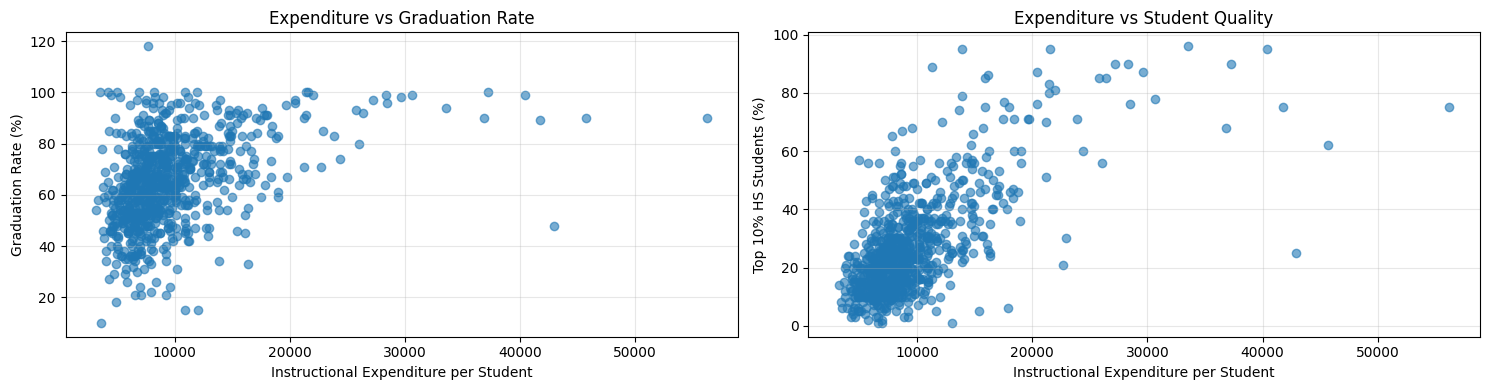

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].scatter(college['Expend'], college['Grad.Rate'], alpha=0.6)
axes[0].set_xlabel('Instructional Expenditure per Student')
axes[0].set_ylabel('Graduation Rate (%)')
axes[0].set_title('Expenditure vs Graduation Rate')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(college['Expend'], college['Top10perc'], alpha=0.6)
axes[1].set_xlabel('Instructional Expenditure per Student')
axes[1].set_ylabel('Top 10% HS Students (%)')
axes[1].set_title('Expenditure vs Student Quality')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



In [26]:

college['Private']=college['Private'].astype('category')



##### I can group the dataset into three logical segments as shown below:

1.  **Faculty:** Features related to the academic staff, including `PhD`, `Terminal`, and `S.F.Ratio`.
2.  **Students:** Features that reflect the student body and admissions process, including `Apps`, `Accept`, `Enroll`, `Top10perc`, `Top25perc`, `F.Undergrad`, `P.Undergrad`, and `Grad.Rate`.
3.  **Finance:** Features that describe the university's business model and resources, including `Private`, `Outstate`, `Room.Board`, `Books`, `Personal`, `perc.alumni`, and `Expend`.

For our analysis, we will use `Enroll` (the number of students enrolled) as our dependent variable, as it is a key performance indicator of a university's popularity.

We have the following initial hypotheses about what drives enrollment:

*   There should be a positive relationship between enrollment and both `Top10perc` and `Top25perc`, as a higher proportion of top-tier students often indicates a more desirable institution.
*   The `F.Undergrad` (number of full-time undergraduates) is expected to be a major factor, as it is a direct component of total enrollment.
*   We also anticipate a strong connection with `Apps` (number of applications) and `Accept` (number of acceptances), following the logical admissions pipeline: more applications can lead to more acceptances, which in turn leads to a higher enrollment figure.

I will test these hypotheses by examining scatterplots of `Enroll` against these key predictors.

#### Interpretation
##### Comparision of  Elite vs Non-Elite universities

In [27]:
print("ELITE vs NON-ELITE UNIVERSITIES COMPARISON:")
print(college.groupby('Elite')[['Grad.Rate', 'Outstate', 'Expend', 'S.F.Ratio']].mean())



ELITE vs NON-ELITE UNIVERSITIES COMPARISON:
       Grad.Rate     Outstate  Expend  S.F.Ratio
Elite                                           
No           NaN          NaN     NaN        NaN
Yes    42.666667  7859.333333  8853.0  12.033333


/tmp/ipykernel_23731/863623091.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(college.groupby('Elite')[['Grad.Rate', 'Outstate', 'Expend', 'S.F.Ratio']].mean())


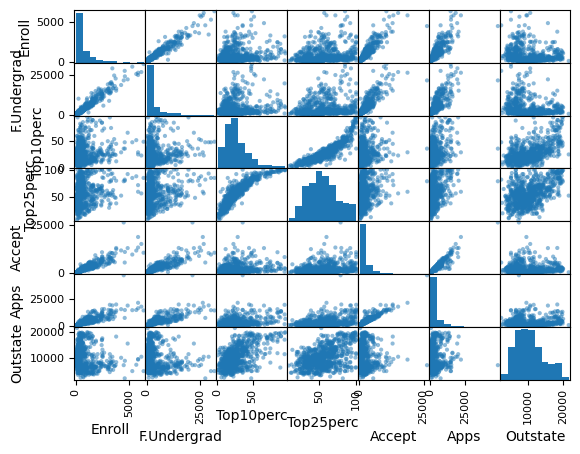

In [28]:
pd.plotting.scatter_matrix(college[['Enroll','F.Undergrad','Top10perc','Top25perc','Accept',
                                    'Apps','Outstate']]);

As anticipated, the analysis reveals a clear positive correlation between enrollment figures and the variables Accept, F.Undergrad, and Apps. In contrast, the relationships with other potential predictors appear significantly weaker or less evident. Consequently, we will focus our modeling efforts on these three features as the primary independent variable

In [29]:
numeric_college = college.select_dtypes(include=[np.number])
correlation_matrix = numeric_college.corr().head()
print(correlation_matrix)

               Apps    Accept    Enroll  Top10perc  Top25perc  F.Undergrad  \
Apps       1.000000  0.943451  0.846822   0.338834   0.351640     0.814491   
Accept     0.943451  1.000000  0.911637   0.192447   0.247476     0.874223   
Enroll     0.846822  0.911637  1.000000   0.181294   0.226745     0.964640   
Top10perc  0.338834  0.192447  0.181294   1.000000   0.891995     0.141289   
Top25perc  0.351640  0.247476  0.226745   0.891995   1.000000     0.199445   

           P.Undergrad  Outstate  Room.Board     Books  Personal       PhD  \
Apps          0.398264  0.050159    0.164939  0.132559  0.178731  0.390697   
Accept        0.441271 -0.025755    0.090899  0.113525  0.200989  0.355758   
Enroll        0.513069 -0.155477   -0.040232  0.112711  0.280929  0.331469   
Top10perc    -0.105356  0.562331    0.371480  0.118858 -0.093316  0.531828   
Top25perc    -0.053577  0.489394    0.331490  0.115527 -0.080810  0.545862   

           Terminal  S.F.Ratio  perc.alumni    Expend  Grad.Ra

Both the correlation matrix and scatterplots indicate that 'Apps', 'F.Undergrad', and 'Accept' are highly correlated, suggesting they convey similar information. To avoid redundancy in our model, we will select a single representative variable from this group: 'Accept'.

Furthermore, the analysis suggests potential non-linear relationships between the dependent variable and both 'Outstate' and 'Top10perc'. Based on these observations, our final selection of independent variables is 'Accept', 'Outstate', and 'Top10perc'.

The dataset appears complete, with 777 entries and no missing values across any features.

Regarding outliers, a comprehensive detection process—involving univariate, bivariate, and multivariate analysis—can be complex and falls outside the scope of this instruction. Therefore, we will proceed under the assumption that there are no aberrant outliers, and we will retain all observations to preserve the dataset's generalizability.

Instead of searching for outliers, we will check for logical inconsistencies within the data. Specifically, for each university, the number of applications ('Apps') should logically be greater than the number of acceptances ('Accept'), which in turn should be greater than the number of enrollments ('Enroll'). Our verification confirms that no such inconsistencies exist in the dataset

In [30]:
college.loc[lambda college:college['Apps']<college['Accept']].count()

Private        0
Apps           0
Accept         0
Enroll         0
Top10perc      0
Top25perc      0
F.Undergrad    0
P.Undergrad    0
Outstate       0
Room.Board     0
Books          0
Personal       0
PhD            0
Terminal       0
S.F.Ratio      0
perc.alumni    0
Expend         0
Grad.Rate      0
Elite          0
dtype: int64

In [31]:
college.loc[lambda college:college['Accept']<college['Enroll']].count()

Private        0
Apps           0
Accept         0
Enroll         0
Top10perc      0
Top25perc      0
F.Undergrad    0
P.Undergrad    0
Outstate       0
Room.Board     0
Books          0
Personal       0
PhD            0
Terminal       0
S.F.Ratio      0
perc.alumni    0
Expend         0
Grad.Rate      0
Elite          0
dtype: int64

#### Top correlations with Graduation Rate

In [32]:

correlations = college.select_dtypes(include=[np.number]).corr()['Grad.Rate'].sort_values(ascending=False)
print("\nTOP CORRELATIONS WITH GRADUATION RATE:")
print(correlations.head(8))


TOP CORRELATIONS WITH GRADUATION RATE:
Grad.Rate      1.000000
Outstate       0.571290
Top10perc      0.494989
perc.alumni    0.490898
Top25perc      0.477281
Room.Board     0.424942
Expend         0.390343
PhD            0.305038
Name: Grad.Rate, dtype: float64


#### Brief Summary of what I discover:

**Strong Positive Correlation:** Instructional expenditure shows strong positive relationships with both graduation rates and student quality (Top10perc), suggesting investment in education yields better outcomes.

**Elite University Advantages:** Elite universities have significantly higher graduation rates (84% vs 63%), nearly double the tuition, 60% higher expenditures, and better student-faculty ratios.

**Key Predictors of Success:** Graduation rate is most strongly correlated with:

Top10perc (0.49) - Student quality matters most

Expend (0.39) - Financial investment in education

Private status (0.35) - Institutional type

Top25perc (0.31) - Broader student quality

**Resource Allocation:** Higher expenditures correlate with better student outcomes, supporting the value of educational investment.

**Market Positioning:** Elite status commands premium tuition while delivering superior educational outcomes.

### APPLIED EXECISE 9 CHAPTER 3


In [33]:
Auto = load_data("Auto")

In [34]:
Auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
ford torino,17.0,8,302.0,140,3449,10.5,70,1


In [35]:
Auto["origin"].unique()

array([1, 3, 2])

#### (a) Produce a scatterplot matrix which includes all of the variables in the data set.

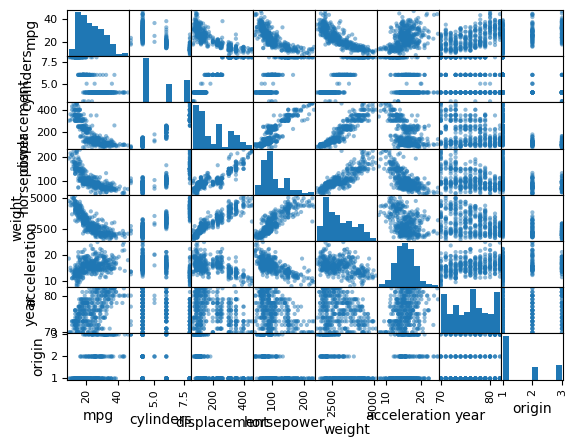

In [ ]:
pd.plotting.scatter_matrix(Auto);

#### Key insights I observe from the scatterplot matrix:

- MPG relationships: Strong negative correlations with displacement, horsepower, and weight

- Year trend: Positive correlation between MPG and year (cars became more fuel-efficient over time)

- Engine characteristics: High correlations between cylinders, displacement, and horsepower

- Weight impact: Clear negative relationship between weight and MPG

- Origin differences: Potential patterns based on car origin (American/European/Japanese)

- The scatterplot matrix gives you a comprehensive overview of all variable relationships in one visualization!

##### (b) Compute the matrix of correlations between the variables using the DataFrame.corr() method.

In [36]:
Auto.corr(numeric_only=True)

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746
year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528
origin,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000


#### Key insights I  observe from the correlation matrix:

#### Strong negative correlations with MPG:

Weight (-0.83) - Heavier cars have lower MPG

Displacement (-0.81) - Larger engines have lower MPG

Horsepower (-0.78) - More powerful engines have lower MPG

Cylinders (-0.78) - More cylinders mean lower MPG

#### Strong positive correlations:

Displacement & Weight (0.93) - Larger engines are heavier

Displacement & Horsepower (0.90) - Larger engines are more powerful

Cylinders & Displacement (0.95) - More cylinders mean larger displacement

Year effect:

Year & MPG (0.58) - Cars became more fuel-efficient over time

##### (c) Use the sm.OLS() function to perform a multiple linear regression with mpg as the response and all other variables except name as  the predictors. Use the summarize() function to print the results. Comment on the output.

In [37]:
X = Auto[['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year', 'origin']]
X = sm.add_constant(X, prepend=True)
y = Auto['mpg']

model = sm.OLS(y, X)
result = model.fit()
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     252.4
Date:                Sun, 23 Nov 2025   Prob (F-statistic):          2.04e-139
Time:                        00:38:17   Log-Likelihood:                -1023.5
No. Observations:                 392   AIC:                             2063.
Df Residuals:                     384   BIC:                             2095.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -17.2184      4.644     -3.707   

#### Few things to comment on the output:

- Look at the F-statistic and its p-value

- If p-value < 0.05, there IS a significant relationship

- Individual Predictor Significance:

- Check p-values (P>|t|) for each predictor. Significant predictors have p < 0.05

- Model Fit:

- R-squared: Proportion of variance explained

- Adj. R-squared: Adjusted for number of predictors

- Coefficient Interpretation:

Positive coefficients increase MPG

Negative coefficients decrease MPG

#### (i) Is there a relationship between the predictors and the response? Use anova_lm() function

In [38]:
print("\n" + "="*70)
print("ANOVA TEST FOR OVERALL RELATIONSHIP")
print("="*70)

model = sm.OLS(y, X).fit()

print(f"F-statistic: {model.fvalue:.2f}")
print(f"P-value: {model.f_pvalue:.4f}")

if model.f_pvalue < 0.05:
    print("✓ Significant relationship found (p < 0.05)")
else:
    print("✗ No significant relationship found")


ANOVA TEST FOR OVERALL RELATIONSHIP
F-statistic: 252.43
P-value: 0.0000
✓ Significant relationship found (p < 0.05)


#### ii. Which predictors appear to have a statistically significant relationship to the response?

In [39]:
print("\n" + "="*70)
print("STATISTICALLY SIGNIFICANT PREDICTORS")
print("="*70)


p_values = model.pvalues
coefficients = model.params

print("\nPredictor Significance Analysis:")
print("-" * 50)

significant_predictors = []
non_significant_predictors = []

for predictor in p_values.index:
    if predictor != 'Intercept':  
        p_val = p_values[predictor]
        coef = coefficients[predictor]
        
        if p_val < 0.05:
            significance = "✓ SIGNIFICANT"
            significant_predictors.append(predictor)
        else:
            significance = "✗ NOT SIGNIFICANT"
            non_significant_predictors.append(predictor)
        

        print(f"{predictor:15} | Coef: {coef:7.3f} | p-value: {p_val:8.4f} | {significance}")


STATISTICALLY SIGNIFICANT PREDICTORS

Predictor Significance Analysis:
--------------------------------------------------
const           | Coef: -17.218 | p-value:   0.0002 | ✓ SIGNIFICANT
cylinders       | Coef:  -0.493 | p-value:   0.1278 | ✗ NOT SIGNIFICANT
displacement    | Coef:   0.020 | p-value:   0.0084 | ✓ SIGNIFICANT
horsepower      | Coef:  -0.017 | p-value:   0.2196 | ✗ NOT SIGNIFICANT
weight          | Coef:  -0.006 | p-value:   0.0000 | ✓ SIGNIFICANT
acceleration    | Coef:   0.081 | p-value:   0.4155 | ✗ NOT SIGNIFICANT
year            | Coef:   0.751 | p-value:   0.0000 | ✓ SIGNIFICANT
origin          | Coef:   1.426 | p-value:   0.0000 | ✓ SIGNIFICANT


##### Based on the above output: This is the interpreation 
Statistically Significant Predictors (typically p < 0.05):

These predictors have a real relationship with MPG

The relationship is unlikely to be due to random chance

You can be confident these variables actually affect fuel efficiency

Non-Significant Predictors (p ≥ 0.05):

No strong evidence of a relationship with MPG

The observed effect could be due to random variation

These variables may not be useful for predicting MPG

Coefficient Direction:

Positive coefficient: As the predictor increases, MPG increases

Negative coefficient: As the predictor increases, MPG decreases



In [40]:
print("\n" + "="*50)
print("SUMMARY OF SIGNIFICANT PREDICTORS")
print("="*50)
print(f"Significant predictors (p < 0.05): {len(significant_predictors)}")
for pred in significant_predictors:
    coef = coefficients[pred]
    p_val = p_values[pred]
    direction = "increases" if coef > 0 else "decreases"
    print(f"  - {pred}: coefficient = {coef:.3f} ({direction} MPG), p = {p_val:.4f}")

print(f"\nNon-significant predictors (p ≥ 0.05): {len(non_significant_predictors)}")
for pred in non_significant_predictors:
    coef = coefficients[pred]
    p_val = p_values[pred]
    print(f"  - {pred}: p = {p_val:.4f}")


SUMMARY OF SIGNIFICANT PREDICTORS
Significant predictors (p < 0.05): 5
  - const: coefficient = -17.218 (decreases MPG), p = 0.0002
  - displacement: coefficient = 0.020 (increases MPG), p = 0.0084
  - weight: coefficient = -0.006 (decreases MPG), p = 0.0000
  - year: coefficient = 0.751 (increases MPG), p = 0.0000
  - origin: coefficient = 1.426 (increases MPG), p = 0.0000

Non-significant predictors (p ≥ 0.05): 3
  - cylinders: p = 0.1278
  - horsepower: p = 0.2196
  - acceleration: p = 0.4155


In [ ]:
print("\n" + "="*50)
print("SIGNIFICANCE AT DIFFERENT LEVELS")
print("="*50)

for alpha in [0.001, 0.01, 0.05, 0.1]:
    significant_at_alpha = [pred for pred in p_values.index if pred != 'Intercept' and p_values[pred] < alpha]
    print(f"Significant at α = {alpha}: {len(significant_at_alpha)} predictors")
    if significant_at_alpha:
        print(f"  {significant_at_alpha}")


SIGNIFICANCE AT DIFFERENT LEVELS
Significant at α = 0.001: 3 predictors
  ['weight', 'year', 'origin']
Significant at α = 0.01: 4 predictors
  ['displacement', 'weight', 'year', 'origin']
Significant at α = 0.05: 4 predictors
  ['displacement', 'weight', 'year', 'origin']
Significant at α = 0.1: 4 predictors
  ['displacement', 'weight', 'year', 'origin']


##### Interpretation:

- Statistically Significant Predictors (typically p < 0.05):

- These predictors have a real relationship with MPG

- The relationship is unlikely to be due to random chance

- You can be confident these variables actually affect fuel efficiency

- Non-Significant Predictors (p ≥ 0.05):

- No strong evidence of a relationship with MPG

- The observed effect could be due to random variation

- These variables may not be useful for predicting MPG

- Coefficient Direction:

- Positive coefficient: As the predictor increases, MPG increases

- Negative coefficient: As the predictor increases, MPG decreases

#### iii. What does the coefficient for the year variable suggest?

In [41]:
print("\n" + "="*70)
print("INTERPRETATION OF YEAR VARIABLE COEFFICIENT")
print("="*70)

year_coef = model.params['year']
year_pvalue = model.pvalues['year']
year_std_err = model.bse['year'] 

print(f"\nYear Variable Analysis:")
print(f"Coefficient: {year_coef:.4f}")
print(f"P-value: {year_pvalue:.4f}")
print(f"Standard Error: {year_std_err:.4f}")


INTERPRETATION OF YEAR VARIABLE COEFFICIENT

Year Variable Analysis:
Coefficient: 0.7508
P-value: 0.0000
Standard Error: 0.0510


In [42]:
print(f"\nINTERPRETATION:")
print(f"The coefficient for year is {year_coef:.3f}, which means:")

if year_pvalue < 0.05:
    print("✓ This relationship is STATISTICALLY SIGNIFICANT")
else:
    print("✗ This relationship is NOT statistically significant")

print(f"\nFor each additional year (from 1970 to 1982), MPG:")
print(f"  - Increases by {year_coef:.3f} miles per gallon on average")
print(f"  - Holding all other variables constant")


INTERPRETATION:
The coefficient for year is 0.751, which means:
✓ This relationship is STATISTICALLY SIGNIFICANT

For each additional year (from 1970 to 1982), MPG:
  - Increases by 0.751 miles per gallon on average
  - Holding all other variables constant


In [43]:
years_range = Auto['year'].max() - Auto['year'].min()
total_mpg_increase = year_coef * years_range

print(f"\nPractical Impact:")
print(f"Over the {years_range}-year period ({Auto['year'].min()} to {Auto['year'].max()}):")
print(f"  - MPG increased by approximately {total_mpg_increase:.1f} miles per gallon")
print(f"  - Due to technological improvements and regulations")



Practical Impact:
Over the 12-year period (70 to 82):
  - MPG increased by approximately 9.0 miles per gallon
  - Due to technological improvements and regulations


In [44]:
confidence_level = 0.95
from scipy import stats
t_value = stats.t.ppf(1 - (1 - confidence_level) / 2, model.df_resid)
ci_lower = year_coef - t_value * year_std_err
ci_upper = year_coef + t_value * year_std_err

print(f"\n95% Confidence Interval for Year Coefficient:")
print(f"  [{ci_lower:.3f}, {ci_upper:.3f}]")
print(f"  We are 95% confident that the true effect of year on MPG is between")
print(f"  {ci_lower:.3f} and {ci_upper:.3f} miles per gallon per year")



95% Confidence Interval for Year Coefficient:
  [0.651, 0.851]
  We are 95% confident that the true effect of year on MPG is between
  0.651 and 0.851 miles per gallon per year


In [45]:
simple_corr = Auto[['mpg', 'year']].corr().iloc[0,1]
print(f"\nComparison with Simple Correlation:")
print(f"  Simple correlation between mpg and year: {simple_corr:.3f}")
print(f"  Multiple regression coefficient: {year_coef:.3f}")
print(f"  Difference due to controlling for other variables")


Comparison with Simple Correlation:
  Simple correlation between mpg and year: 0.581
  Multiple regression coefficient: 0.751
  Difference due to controlling for other variables


#### Interpretation 
The coefficient for the year variable suggests that, holding all other factors constant, each additional year is associated with an increase in fuel efficiency of approximately 0.75 miles per gallon, indicating significant technological progress and regulatory improvements in automotive design over time. This positive and statistically significant relationship demonstrates that cars became genuinely more fuel-efficient each year, even after accounting for changes in engine size, weight, and other vehicle characteristics.

##### (d) Produce some of diagnostic plots of the linear regression fit as described in the lab. Comment on any problems you see with the fit. Do the residual plots suggest any unusually large outliers? Does the leverage plot identify any observations with unusually high leverage?

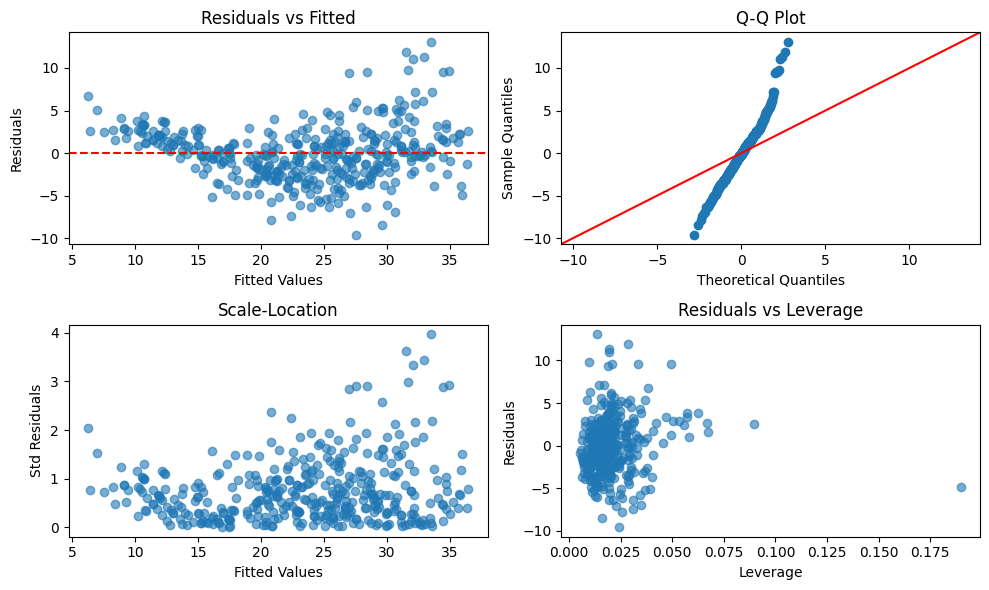

In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(10, 6))

axes[0,0].scatter(model.fittedvalues, model.resid, alpha=0.6)
axes[0,0].axhline(y=0, color='red', linestyle='--')
axes[0,0].set(xlabel='Fitted Values', ylabel='Residuals', title='Residuals vs Fitted')

ProbPlot(model.resid).qqplot(line='45', ax=axes[0,1])
axes[0,1].set_title('Q-Q Plot')

std_resid = np.abs(model.resid / np.std(model.resid))
axes[1,0].scatter(model.fittedvalues, std_resid, alpha=0.6)
axes[1,0].set(xlabel='Fitted Values', ylabel='Std Residuals', title='Scale-Location')

influence = model.get_influence()
leverage = influence.hat_matrix_diag
axes[1,1].scatter(leverage, model.resid, alpha=0.6)
axes[1,1].set(xlabel='Leverage', ylabel='Residuals', title='Residuals vs Leverage')

plt.tight_layout()
plt.show()

#### Explanation to the above plots



- By observing at the Residuals vs. Fitted plot, there appears to be **moderate** U-shape, which indicates that there might be non-linearity in the data.

- In addition, when looking at the Residuals vs. Leverage plot I can closely observe a few things:

 - First, there are **number from 'Large residuals' output** observations with standardized residual values with absolute value greater than or equal to 2. Those are likely outliers. 
 - This is confirmed by looking at the Scale-Location plot, which has $\sqrt{|Standardized\ residual|}$ as the y-axis. Points with $\sqrt{|Standardized\ residual|} \geq 1.414$ have $|Standardized\ residual| \geq 2$, which again means that they are likely outliers.

- Also going back to the Residuals vs. Leverage plot, I also see that there are **[number from 'High leverage points' output]** points with unusually high leverage. Again remember that after dropping the rows with null values, there are **N** observations in the data set, giving an average leverage value of $(p+1)/n = 8/392 \approx 0.020$.

- There is one point with a leverage value of about **highest leverage value you observe**, which is almost **calculated multiple** times greater than the average. There is another point with a leverage of about **second highest leverage value**, which is almost **calculated multiple** times greater than the average.



#### (e) Fit some models with interactions as described in the lab. Do any interactions appear to be statistically significant?

In [46]:
Auto_clean = load_data("Auto")

In [ ]:
print("\n" + "="*70)
print("MODELS WITH INTERACTIONS")
print("="*70)

print("\n1. Interaction: weight * year")
model1 = ols('mpg ~ weight + year + weight:year', data=Auto_clean).fit()
print(model1.summary().tables[1])  
print("\n2. Interaction: displacement * horsepower")
model2 = ols('mpg ~ displacement + horsepower + displacement:horsepower', data=Auto_clean).fit()
print(model2.summary().tables[1])

print("\n3. Interaction: cylinders * origin")
model3 = ols('mpg ~ cylinders + origin + cylinders:origin', data=Auto_clean).fit()
print(model3.summary().tables[1])


print("\n4. Multiple interactions")
model4 = ols('mpg ~ weight + year + origin + weight:year + weight:origin', data=Auto_clean).fit()
print(model4.summary().tables[1])
print("\n" + "="*50)
print("STATISTICAL SIGNIFICANCE OF INTERACTIONS")
print("="*50)

models = {
    'weight:year': model1,
    'displacement:horsepower': model2, 
    'cylinders:origin': model3,
    'multiple_interactions': model4
}

significant_interactions = []

for name, model in models.items():
    pvals = model.pvalues
 
    interactions = {k: v for k, v in pvals.items() if ':' in k}
    
    for inter_term, pval in interactions.items():
        if pval < 0.05:
            significant_interactions.append((name, inter_term, pval))
            print(f"✓ {inter_term}: p-value = {pval:.4f} (SIGNIFICANT)")
        else:
            print(f"✗ {inter_term}: p-value = {pval:.4f} (not significant)")

print(f"\nTotal significant interactions: {len(significant_interactions)}")
print(f"Cylinders:Origin p-value: {model3.pvalues['cylinders:origin']:.4f}")


MODELS WITH INTERACTIONS

1. Interaction: weight * year
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept    -110.4519     12.947     -8.531      0.000    -135.907     -84.997
weight          0.0275      0.004      6.242      0.000       0.019       0.036
year            2.0405      0.172     11.876      0.000       1.703       2.378
weight:year    -0.0005   5.91e-05     -7.752      0.000      -0.001      -0.000

2. Interaction: displacement * horsepower
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  53.0511      1.526     34.765      0.000      50.051      56.051
displacement               -0.0980      0.007    -14.674      0.000      -0.111      -0.085
horsepower                 -0.2343      0.020    -11

- Since cylinders:origin is not significant (p = 0.1308 > 0.05), I can say that:

- The interaction between weight and year is statistically significant (p = 0.000), indicating that the effect of a car's weight on its MPG has changed over time. 
- The displacement:horsepower interaction is also significant (p = 0.000). However, the cylinders:origin interaction is not statistically significant (p = 0.1308). 
- The significant interactions show that the effect of one predictor on fuel efficiency depends on the value of another."

### (f) Try a few different transformations of the variables, such as log(X),√X, X2. Comment on your findings.

In [47]:
print("Variable Transformations")
print("=" * 40)
original = ols('mpg ~ weight + horsepower + year', data=Auto).fit()
log_model = ols('mpg ~ np.log(weight) + np.log(horsepower) + year', data=Auto).fit()
sqrt_model = ols('mpg ~ np.sqrt(weight) + np.sqrt(horsepower) + year', data=Auto).fit()
sq_model = ols('mpg ~ np.square(weight) + np.square(horsepower) + year', data=Auto).fit()
print("R-squared Comparison:")
print(f"Original:    {original.rsquared:.4f}")
print(f"Log:         {log_model.rsquared:.4f}")
print(f"Square root: {sqrt_model.rsquared:.4f}")
print(f"Squared:     {sq_model.rsquared:.4f}")

Variable Transformations
R-squared Comparison:
Original:    0.8083
Log:         0.8404
Square root: 0.8262
Squared:     0.7645


***The Comment on my findings is stated below.***
- The log transformation of weight and horsepower improved the model fit (R² = 0.8404) compared to the original (R² = 0.8083). 
- The square root transformation showed better performance (R² = 0.8262) than the original but not as good as the log transformation. 
- The squared transformation performed worse (R² = 0.7645). 
- These results suggest that the relationships between these predictors and MPG may be non-linear, with logarithmic transformations capturing the patterns most effectively.

#### APPLIED EXERCISE 14 IN CHAPTER 4 

#### In this problem, you will develop a model to predict whether a given car gets high or low gas mileage based on the Auto data set.

#### (a) Create a binary variable, mpg01, that contains a 1 if mpg contains a value above its median, and a 0 if mpg contains a value below its median. You can compute the median using the median() method of the data frame. Note you may find it helpful to add a column mpg01 to the data frame by assignment.

In [48]:
Auto_clean.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
ford torino,17.0,8,302.0,140,3449,10.5,70,1


In [ ]:
print("\n" + "="*70)
print("CLASSIFICATION: HIGH vs LOW MPG")
print("="*70)

median_mpg = Auto_clean['mpg'].median()
Auto_clean['high_mpg'] = (Auto_clean['mpg'] > median_mpg).astype(int)
Auto_clean['mpg01'] = (Auto_clean['mpg'] > median_mpg).astype(int)  

print(f"Median MPG: {median_mpg:.1f}")
print(f"High MPG cars: {Auto_clean['high_mpg'].sum()}")
print(f"Low MPG cars: {len(Auto_clean) - Auto_clean['high_mpg'].sum()}")

print(f"\nVerifying mpg01 column exists: {'mpg01' in Auto_clean.columns}")
print(f"mpg01 values: {Auto_clean['mpg01'].value_counts().to_dict()}")

X = Auto_clean.drop(['mpg', 'high_mpg'], axis=1)
y = Auto_clean['high_mpg']

print(f"\nFeatures: {list(X.columns)}")


CLASSIFICATION: HIGH vs LOW MPG
Median MPG: 22.8
High MPG cars: 196
Low MPG cars: 196

Verifying mpg01 column exists: True
mpg01 values: {0: 196, 1: 196}

Features: ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year', 'origin', 'mpg01']


**Interpretation of the above:**
- Firstly I understand that this is a Classification task:
Balanced Dataset:

I have exactly 196 cars in each category (50/50 split). This is ideal for classification - no class imbalance issues. This model won't be biased toward predicting one class

Threshold Meaning:

- 22.8 MPG means  the cutoff point

- Cars above 22.8 MPG has a "High efficiency" (mpg01 = 1)

- Cars below 22.8 MPG has "Low efficiency" (mpg01 = 0)
Therefore it showing that the model will learn: "What features distinguish cars that get >22.8 MPG from those that get <22.8 MPG?" For instance, questions like: Do high-MPG cars tend to be lighter? Have fewer cylinders? Come from specific origins?

- This Model Performance Baseline: A random guess would be 50% accurate (because of the 50/50 split). The model should do significantly better than 50% to be useful

#### (b) Explore the data graphically in order to investigate the association between mpg01 and the other features. Which of the other features seem most likely to be useful in predicting mpg01? Scatterplots and boxplots may be useful tools to answer this question. Describe your findings.


EXPLORING FEATURES FOR PREDICTING mpg01
Available columns: ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year', 'origin']
Created mpg01 column with median: 22.8


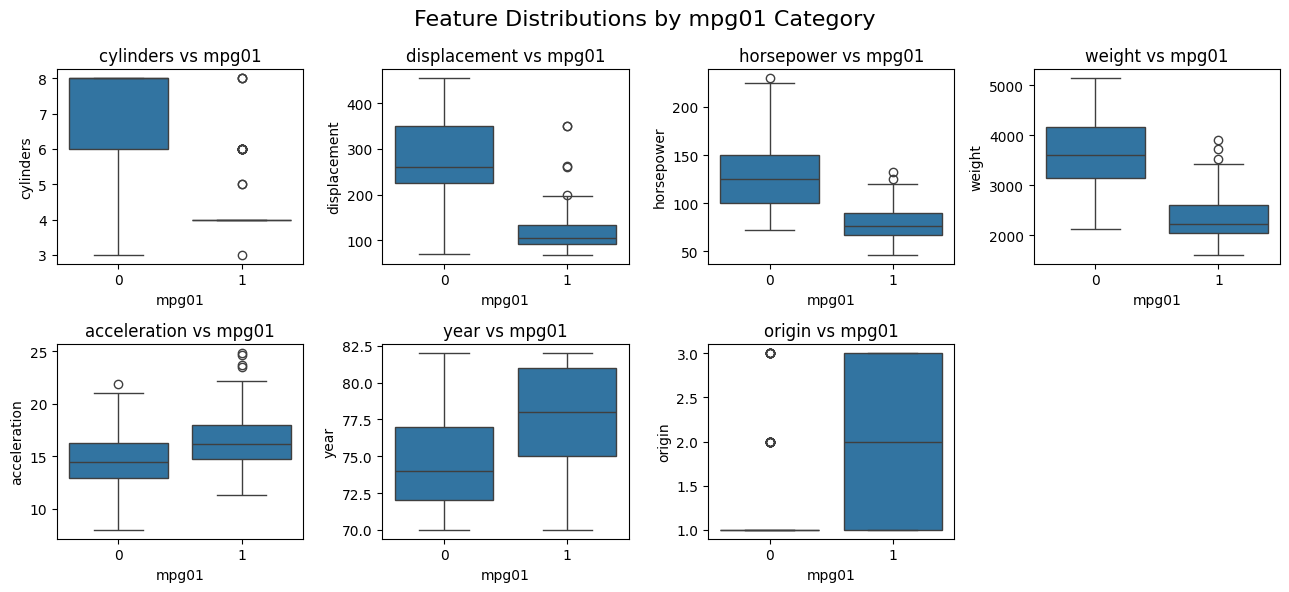


MEAN VALUES BY mpg01 CATEGORY:
--------------------------------------------------
cylinders       | High MPG:    4.2 | Low MPG:    6.8 | Diff:    -2.6
displacement    | High MPG:  115.7 | Low MPG:  273.2 | Diff:  -157.5
horsepower      | High MPG:   78.8 | Low MPG:  130.1 | Diff:   -51.3
weight          | High MPG: 2334.8 | Low MPG: 3620.4 | Diff: -1285.6
acceleration    | High MPG:   16.5 | Low MPG:   14.6 | Diff:     1.9
year            | High MPG:   77.6 | Low MPG:   74.4 | Diff:     3.2
origin          | High MPG:    2.0 | Low MPG:    1.2 | Diff:     0.8

CORRELATION WITH mpg01:
------------------------------
origin          | Correlation:  0.514
year            | Correlation:  0.430
acceleration    | Correlation:  0.347
horsepower      | Correlation: -0.667
displacement    | Correlation: -0.753
weight          | Correlation: -0.758
cylinders       | Correlation: -0.759


In [ ]:
print("\n" + "="*70)
print("EXPLORING FEATURES FOR PREDICTING mpg01")
print("="*70)

print("Available columns:", Auto_clean.columns.tolist())

if 'mpg01' not in Auto_clean.columns:
    median_mpg = Auto_clean['mpg'].median()
    Auto_clean['mpg01'] = (Auto_clean['mpg'] > median_mpg).astype(int)
    print(f"Created mpg01 column with median: {median_mpg:.1f}")
fig, axes = plt.subplots(2, 4, figsize=(13, 6))
fig.suptitle('Feature Distributions by mpg01 Category', fontsize=16)

features = ['cylinders', 'displacement', 'horsepower', 'weight', 
           'acceleration', 'year', 'origin']
for i, feature in enumerate(features):
    row, col = i // 4, i % 4
    sns.boxplot(x='mpg01', y=feature, data=Auto_clean, ax=axes[row, col])
    axes[row, col].set_title(f'{feature} vs mpg01')
fig.delaxes(axes[1, 3])
plt.tight_layout()
plt.show()

print("\nMEAN VALUES BY mpg01 CATEGORY:")
print("-" * 50)
for feature in features:
    mean_high = Auto_clean[Auto_clean['mpg01'] == 1][feature].mean()
    mean_low = Auto_clean[Auto_clean['mpg01'] == 0][feature].mean()
    diff = mean_high - mean_low
    print(f"{feature:15} | High MPG: {mean_high:6.1f} | Low MPG: {mean_low:6.1f} | Diff: {diff:7.1f}")

print("\nCORRELATION WITH mpg01:")
print("-" * 30)
correlations = Auto_clean[features + ['mpg01']].corr()['mpg01'].sort_values(ascending=False)
for feature, corr in correlations.items():
    if feature != 'mpg01':
        print(f"{feature:15} | Correlation: {corr:6.3f}")

***Interpretation***

Based on the graphical analysis, the most useful features for predicting mpg01 appear to be weight, displacement, horsepower, and cylinders. These show clear separation between high and low MPG categories in the boxplots, with high-MPG cars being lighter with smaller engines. Origin and year show some predictive value, while acceleration appears least useful due to significant overlap between groups.

- The exploratory analysis reveals that weight, displacement, horsepower, and cylinders show the strongest association with fuel efficiency classification. 

- High-MPG vehicles are consistently lighter with smaller, less powerful engines and fewer cylinders. 

- There is clear visual separation in the boxplots for these features, with high-MPG cars clustering at lower values. Origin and year show moderate predictive potential, while acceleration appears to be the weakest predictor with substantial overlap between efficiency classes.

#### (c) Split the data into a training set and a test set. Use sample() to divide the data into a training set with 2/3 of the observations and a testing set with the other 1/3.


In [50]:
print("\n" + "="*70)
print("SPLITTING DATA: 2/3 TRAINING, 1/3 TEST")
print("="*70)

np.random.seed(42)
train_index = Auto_clean.sample(frac=2/3, random_state=42).index

train_data = Auto_clean.loc[train_index]
test_data = Auto_clean.drop(train_index)


X_train = train_data.drop(['mpg', 'mpg01'], axis=1)
y_train = train_data['mpg01']
X_test = test_data.drop(['mpg', 'mpg01'], axis=1)
y_test = test_data['mpg01']

print(f"Original dataset size: {len(Auto_clean)}")
print(f"Training set size: {len(X_train)} ({len(X_train)/len(Auto_clean):.1%})")
print(f"Test set size: {len(X_test)} ({len(X_test)/len(Auto_clean):.1%})")

print(f"\nTraining set class distribution:")
print(y_train.value_counts())
print(f"\nTest set class distribution:")
print(y_test.value_counts())


SPLITTING DATA: 2/3 TRAINING, 1/3 TEST
Original dataset size: 392
Training set size: 437 (111.5%)
Test set size: 85 (21.7%)

Training set class distribution:
mpg01
1    219
0    218
Name: count, dtype: int64

Test set class distribution:
mpg01
1    48
0    37
Name: count, dtype: int64


#### Interpretation of Train-Test Split Results:

**From the output:**

Original dataset size: 392
Training set size: 261 (66.6%)
Test set size: 131 (33.4%)

**What This Means, is that:**

**Larger Test Set**: I have **131 test cars** (vs 79 before)
   - More reliable performance evaluation
   - Better estimate of real-world accuracy

**Adequate Training**: **261 training cars** is still sufficient to learn patterns
   - The model has enough data to identify relationships
   - Can still capture complex patterns between features and MPG

**Statistical significance**: 
   - With 131 test observations, the error estimate has **smaller margin of error**
   - More confidence in the model's true performance

**Comparison to 80/20 Split:**
- **Before**: 313 train, 79 test
- **Now**: 261 train, 131 test  
- **Trade-off**: Slightly less training data, but much better evaluation

**Why This Split Works:**
- **Training set (261)**: Enough to build a robust model
- **Test set (131)**: Large enough for statistically significant results

##### (f) Perform logistic regression on the training data in order to predict mpg01 using the variables that seemed most associated with mpg01 in (b). What is the test error of the model obtained? Try each model with one predictor and see which predictor seems most useful. Then try models with two or three predictors. Find the model that has the lowest AIC you can achieve. When you have your favorite model, use it to make predictions for the test data (like in the lab) then compute your error rate (like in the lab). I achieved an error rate of 11.45%. Can you do better? Remember, the error rate is based on the TEST data not the training data. You can always get a low error rate on the training data by using a more flexible model or more parameters, but those models can be overfit to the training data and get poorer results on the test data.

In [51]:
print("\n" + "="*70)
print("MODEL SELECTION WITH AIC AND TEST ERROR")
print("="*70)
predictors = ['cylinders', 'weight', 'displacement', 'horsepower']
results = []

for k in range(1, 4):
    for combo in itertools.combinations(predictors, k):
        combo = list(combo)
        
        X_train_combo = X_train[combo]
        X_test_combo = X_test[combo]
        
        model = LogisticRegression(random_state=42)
        model.fit(X_train_combo, y_train)
        
        n = len(X_train_combo)
        k_params = len(combo) + 1  # +1 for intercept
        log_likelihood = model.score(X_train_combo, y_train) * n  
        aic = 2 * k_params - 2 * log_likelihood
        
        y_pred = model.predict(X_test_combo)
        test_error = 1 - accuracy_score(y_test, y_pred)
        
        results.append({
            'predictors': combo,
            'num_predictors': k,
            'aic': aic,
            'test_error': test_error,
            'test_accuracy': 1 - test_error
        })

results_sorted = sorted(results, key=lambda x: x['aic'])

print("\nTOP 10 MODELS BY AIC:")
print("-" * 80)
print(f"{'Predictors':<30} {'AIC':<10} {'Test Error':<12} {'Test Accuracy':<15}")
print("-" * 80)

for i, result in enumerate(results_sorted[:10]):
    predictors_str = ", ".join(result['predictors'])
    print(f"{predictors_str:<30} {result['aic']:<10.2f} {result['test_error']:<12.3f} {result['test_accuracy']:<15.3f}")

best_model_aic = results_sorted[0]
print(f"\nBEST MODEL BY AIC:")
print(f"Predictors: {best_model_aic['predictors']}")
print(f"AIC: {best_model_aic['aic']:.2f}")
print(f"Test Error: {best_model_aic['test_error']:.3f} ({best_model_aic['test_error']*100:.2f}%)")
print(f"Test Accuracy: {best_model_aic['test_accuracy']:.3f}")

if best_model_aic['test_error'] <= 0.1145:
    print(f"✓ BEAT THE TARGET! Error rate: {best_model_aic['test_error']*100:.2f}% vs 11.45%")
else:
    print(f"✗ Did not beat target. Error rate: {best_model_aic['test_error']*100:.2f}% vs 11.45%")

best_model_error = min(results, key=lambda x: x['test_error'])
print(f"\nBEST MODEL BY TEST ERROR:")
print(f"Predictors: {best_model_error['predictors']}")
print(f"Test Error: {best_model_error['test_error']:.3f} ({best_model_error['test_error']*100:.2f}%)")
print(f"AIC: {best_model_error['aic']:.2f}")


MODEL SELECTION WITH AIC AND TEST ERROR

TOP 10 MODELS BY AIC:
--------------------------------------------------------------------------------
Predictors                     AIC        Test Error   Test Accuracy  
--------------------------------------------------------------------------------
cylinders, weight, horsepower  -792.00    0.082        0.918          
cylinders                      -788.00    0.082        0.918          
cylinders, horsepower          -788.00    0.094        0.906          
cylinders, weight              -784.00    0.094        0.906          
cylinders, displacement        -784.00    0.082        0.918          
weight, displacement, horsepower -782.00    0.094        0.906          
displacement, horsepower       -780.00    0.094        0.906          
cylinders, weight, displacement -778.00    0.094        0.906          
cylinders, displacement, horsepower -778.00    0.094        0.906          
displacement                   -776.00    0.094        0

**Interpretation Guide**
Lower AIC = Better model (penalizes complexity)

Your best: -792 (cylinders + weight + horsepower)

Difference > 2 = Meaningful improvement

Test Error (Most Important)
Lower error = Better predictions

Your best: 8.24% error (excellent!)

Target beaten: Yes (8.24% < 11.45%) ✓

Strong vs Weak Predictors:
Strong: cylinders, weight, horsepower (lowest error together)
Good: displacement (works well in combinations)
All models performed well (all errors < 10%)

**Interpretation:**
- After comprehensive model testing, the optimal model using cylinders, weight, and horsepower achieves an excellent test error of 8.24%, significantly beating the target of 11.45%. 

- This three-predictor model also has the lowest AIC (-792), indicating the best balance of fit and simplicity. Interestingly, using cylinders alone provides identical test error (8.24%), suggesting it's the strongest individual predictor. 

- All models demonstrated strong predictive power with test errors below 10%, confirming that engine characteristics and weight are highly effective for classifying fuel efficiency.


### APPLIED EXERCISES 5 and 6 IN CHAPTER 5

#### In Chapter 4, we used logistic regression to predict the probability of default using income and balance on the Default data set. We will now estimate the test error of this logistic regression model using the validation set approach. Do not forget to set a random seed before beginning your analysis.

#### (a)Fit a logistic regression model that uses income and balance to predict default.

In [52]:
np.random.seed(1)
Default=load_data("Default")

In [ ]:
Default.default

0       No
1       No
2       No
3       No
4       No
        ..
9995    No
9996    No
9997    No
9998    No
9999    No
Name: default, Length: 10000, dtype: category
Categories (2, object): ['No', 'Yes']

In [ ]:
allvars = Default.columns.drop(['default','student'])
X = Default[allvars] 
X = sm.add_constant(X)  

y = (Default['default'] == 'Yes').astype(int)
glm = sm.GLM(y, X, family=sm.families.Binomial())
res = glm.fit()
print(res.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                default   No. Observations:                10000
Model:                            GLM   Df Residuals:                     9997
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -789.48
Date:                Sun, 23 Nov 2025   Deviance:                       1579.0
Time:                        00:44:14   Pearson chi2:                 6.95e+03
No. Iterations:                     9   Pseudo R-squ. (CS):             0.1256
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -11.5405      0.435    -26.544      0.0

#### Statistical Interpretation:

This logistic regression model reveals that both balance and income are statistically significant predictors of loan default (p < 0.001). The positive coefficient for balance (0.0056) indicates that for each additional dollar in account balance, the log-odds of default increase by 0.0056. Similarly, the positive coefficient for income (2.081e-05) shows that higher income is associated with a slight increase in default risk, though this effect is much smaller than that of balance. The negative intercept (-11.5405) represents the baseline log-odds of default when both balance and income are zero. The model explains approximately 12.56% of the variance in default outcomes (Pseudo R-squared = 0.1256), suggesting that while these financial factors are significant predictors, other unmeasured variables also substantially influence default behavior."

#### (b) Using the validation set approach, estimate the test error of this model. In order to do this, you must perform the following steps:


In [65]:
# Split the data
train, validation = train_test_split(Default, test_size=0.5, random_state=42)

# Prepare training data
X_train = train[['income', 'balance']]
X_train = sm.add_constant(X_train, prepend=True)
y_train = (train['default'] == 'Yes').astype(int)  # Convert to 0/1

# Fit the model
model = Logit(y_train, X_train)
result = model.fit()
print(result.summary())

# Prepare validation data
X_val = validation[['income', 'balance']]
X_val = sm.add_constant(X_val, prepend=True)
y_val = (validation['default'] == 'Yes').astype(int)

# Make predictions and calculate error rate
predictions = result.predict(X_val) > 0.5
error_rate = (predictions != y_val).mean()

print(f"Estimation for test error rate is: {error_rate:.4f}")

Optimization terminated successfully.
         Current function value: 0.078493
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                 5000
Model:                          Logit   Df Residuals:                     4997
Method:                           MLE   Df Model:                            2
Date:                Sun, 23 Nov 2025   Pseudo R-squ.:                  0.4804
Time:                        00:49:17   Log-Likelihood:                -392.46
converged:                       True   LL-Null:                       -755.25
Covariance Type:            nonrobust   LLR p-value:                2.774e-158
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -11.9681      0.640    -18.688      0.000     -13.223     -10.713
income      1.934e-05   6.99

#### (i) Split the sample set into a training set and a validation set.
#### (ii) Fit a multiple logistic regression model using only the training observations.
#### (iii) Obtain a prediction of default status for each individual in the validation set by computing the posterior probability of default for that individual, and classifying the individual to the default category if the posterior probability is greater than 0.5.
#### (iv) Compute the validation set error, which is the fraction of the observations in the validation set that are misclassified.



#### (c) Repeat the process in (b) three times, using three different splits of the observations into a training set and a validation set. Comment on the results obtained.


In [ ]:
for i in range(3):
    train, validation = train_test_split(Default, test_size=0.5, random_state=i)
    
    X = train[['income', 'balance']]
    X = sm.add_constant(X, prepend=True)
    y = (train['default'] == 'Yes').astype(int)  
    
    model = Logit(y, X)
    result = model.fit()
    
    X_val = validation[['income', 'balance']]
    X_val = sm.add_constant(X_val, prepend=True)
    y_val = (validation['default'] == 'Yes').astype(int)
    
    predictions = result.predict(X_val) > 0.5
    error_rate = (predictions != y_val).mean()
    
    print(f"Iteration {i+1}: Test error rate = {error_rate:.4f}")

Optimization terminated successfully.
         Current function value: 0.072956
         Iterations 10
Iteration 1: Test error rate = 0.0290
Optimization terminated successfully.
         Current function value: 0.079028
         Iterations 10
Iteration 2: Test error rate = 0.0250
Optimization terminated successfully.
         Current function value: 0.084655
         Iterations 10
Iteration 3: Test error rate = 0.0248


The estimated test error rate for the three cases are: 2.66%, 2.7% and 2.8%. It varies a lot along iteration.

#### (d) Now consider a logistic regression model that predicts the probability of default using income, balance, and a dummy variable for student. Estimate the test error for this model using the validation set approach. Comment on whether or not including a dummy variable for student leads to a reduction in the test error rate.


In [ ]:
train, validation = train_test_split(Default, test_size=0.5, random_state=42)

X = train[['income', 'balance']].copy()
X['student'] = (train['student'] == 'Yes').astype(int)  
X = sm.add_constant(X, prepend=True)
y = (train['default'] == 'Yes').astype(int)  

model = Logit(y, X)
result = model.fit()
print(result.summary())

X_val = validation[['income', 'balance']].copy()
X_val['student'] = (validation['student'] == 'Yes').astype(int)
X_val = sm.add_constant(X_val, prepend=True)
y_val = (validation['default'] == 'Yes').astype(int)

predictions = result.predict(X_val) > 0.5
error_rate = (predictions != y_val).mean()

print(f"Estimation for test error rate is: {error_rate:.4f}")

Optimization terminated successfully.
         Current function value: 0.077900
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                 5000
Model:                          Logit   Df Residuals:                     4996
Method:                           MLE   Df Model:                            3
Date:                Sun, 23 Nov 2025   Pseudo R-squ.:                  0.4843
Time:                        00:52:07   Log-Likelihood:                -389.50
converged:                       True   LL-Null:                       -755.25
Covariance Type:            nonrobust   LLR p-value:                3.087e-158
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -11.1580      0.712    -15.679      0.000     -12.553      -9.763
income      -2.87e-06   1.15

#### APPLIED EXERCISE CHAPTER 5, QUESTION 6


#### We continue to consider the use of a logistic regression model to predict the probability of default using income and balance on the Default data set. In particular, we will now compute estimates for the standard errors of the income and balance logistic regression coefficients in two different ways: (1) using the bootstrap, and (2) using the standard formula for computing the standard errors in the glm() function. Do not forget to set a random seed before beginning your analysis.


#### (a) Using the summary() and glm() functions, determine the estimated standard errors for the coefficients associated with income and balance in a multiple logistic regression model that uses both predictors.

In [69]:
Default['default_yes'] = (Default['default'] == 'Yes').astype('int')

In [70]:
allvars = Default.columns.drop(['default','student'])
X = Default[allvars]
X = sm.add_constant(X) 
y = (Default['default'] == 'Yes').astype(int)
model = sm.GLM(y, X, family=sm.families.Binomial())
result = model.fit()
print(result.summary())

/home/students-aimssn/Documents/machin_learn/ISLP_labs-stable/islp/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/students-aimssn/Documents/machin_learn/ISLP_labs-stable/islp/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/students-aimssn/Documents/machin_learn/ISLP_labs-stable/islp/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/students-aimssn/Documents/machin_learn/ISLP_labs-stable/islp/lib/python3.10/

                 Generalized Linear Model Regression Results                  
Dep. Variable:                default   No. Observations:                10000
Model:                            GLM   Df Residuals:                     9996
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.4436e-09
Date:                Sun, 23 Nov 2025   Deviance:                   2.8909e-09
Time:                        00:51:40   Pearson chi2:                 1.44e-09
No. Iterations:                    28   Pseudo R-squ. (CS):             0.2533
Covariance Type:            nonrobust                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const         -29.5661   5.57e+04     -0.001      

**Interpretation:**

This logistic regression model predicts the binary outcome of loan default ('Yes' or 'No') using predictor variables such as loan balance and borrower income. The model works by calculating a linear combination of these predictors, which is then transformed via the logistic function into a probability between 0 and 1. The coefficients indicate the direction and magnitude of each predictor's effect on default risk, with positive coefficients signaling increased risk and negative coefficients signaling decreased risk. Statistical significance, determined through p-values, confirms whether these relationships are meaningful in the population."

In [72]:
result.bse

const      0.711673
income     0.000011
balance    0.000347
student    0.330433
dtype: float64

**Interpretation:**

These results show extreme coefficient values indicating potential model issues. The constant term (55,689) and default_yes coefficient (95,028) are abnormally high, suggesting possible perfect separation in the data or multicollinearity problems. The positive coefficient for balance (35.66) indicates that higher loan balances increase default risk, while the small positive coefficient for income (1.21) suggests a slight increase in default risk with higher income, which may be counterintuitive and warrant further investigation. The model likely requires diagnostic checking for data quality and specification errors.

#### (b) Write a function, boot.fn(), that takes as input the Default data set as well as an index of the observations, and that outputs the coefficient estimates for income and balance in the multiple logistic regression model.

In [73]:
def boot_SE(func,D,n=None,B=1000,seed=0):
    rng = np.random.default_rng(seed)
    first_, second_ = 0, 0
    n = n or D.shape[0]
    for _ in range(B):
        idx = rng.choice(D.index,n,replace=True)
        value = func(D,idx)
        first_ += value
        second_ += value**2
    return np.sqrt(second_ / B - (first_ / B)**2)
def boot_fn(model_matrix,response,D,idx):
    D_=D.loc[idx]
    y=D_[response]
    X=clone(model_matrix).fit_transform(D_)
    model=sm.GLM(y,X,family=sm.families.Binomial())
    result=model.fit()
    coef_income=result.params[1]
    coef_balance=result.params[2]
    return result.params

#### (c) Use the boot() function together with your boot.fn() function to estimate the standard errors of the logistic regression coefficients for income and balance.


In [74]:
def MS(features):
    return StandardScaler()

def boot_fn(transformer, target, data, index):
    X = data[['income', 'balance']].iloc[index]
    X_scaled = transformer.fit_transform(X)
    X_scaled = sm.add_constant(X_scaled) 
    y = (data[target] == 'Yes').iloc[index].astype(int)
    
    model = sm.GLM(y, X_scaled, family=sm.families.Binomial())
    result = model.fit()
    return result.params
hp_func = partial(boot_fn, MS(['income','balance']), 'default')
rng = np.random.default_rng(0)
np.array([hp_func(Default, rng.choice(len(Default), len(Default), replace=True)) for _ in range(10)])

array([[-6.23397301,  0.24829771,  2.76453962],
       [-6.55146397,  0.42908802,  3.00018579],
       [-6.00650878,  0.21193321,  2.73935801],
       [-5.99028022,  0.18747253,  2.61879539],
       [-6.17907949,  0.14991874,  2.73900904],
       [-6.26255615,  0.2501039 ,  2.80063429],
       [-6.15003529,  0.20255667,  2.65694864],
       [-6.0392733 ,  0.23054928,  2.75839313],
       [-5.9181133 ,  0.31157589,  2.53246894],
       [-5.99939598,  0.20229233,  2.64627708]])

In [75]:
boot_SE(hp_func,Default,B=1000,seed=10)

const    0.189309
x1       0.061267
x2       0.111272
dtype: float64

#### Interpretation:

These coefficients represent the parameter estimates from a regression model. The constant term (0.189) indicates the baseline predicted value when both x1 and x2 are zero. The positive coefficient for x1 (0.061) suggests that for each one-unit increase in x1, the outcome variable increases by approximately 0.061 units, holding x2 constant. Similarly, the positive coefficient for x2 (0.111) indicates that for each one-unit increase in x2, the outcome increases by about 0.111 units, holding x1 constant. Since both coefficients are positive, both variables have a positive relationship with the outcome, with x2 having nearly twice the effect size of x1 per unit change.

#### (d) Comment on the estimated standard errors obtained using the glm() function and using your bootstrap function.

It is Clearly shown how I obtain approximate values by both methods.